Detyre Kursi Inteligjence Artificiale

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # styling the plots
from sklearn.preprocessing import LabelEncoder  # features in our dataset
from imblearn.over_sampling import SMOTE  # for imbalance class distribution, perform oversampling
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV  # splitting the data, hyperparameter tuning
from sklearn.tree import DecisionTreeClassifier   # we have a classification problem, 1st alg
from sklearn.ensemble import RandomForestClassifier # 2nd alg
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import cohen_kappa_score
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim


In [70]:
df = pd.read_csv("AutismDataset.csv")

In [71]:
df.shape  # printim i permasave te datasetit

(800, 22)

In [72]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38.172746,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47.750517,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7.380373,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23.561927,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43.205790,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [73]:
pd.set_option("display.max_columns", None) #printim i te gjitha kolonave me emer t gjate

In [74]:
df.info() # kemi 22 kolona/features, disa jane numerike e disa kategorike

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    str    
 13  ethnicity        800 non-null    str    
 14  jaundice         800 non-null    str    
 15  austim           800 non-null    str    
 16  contry_of_res    800 non-null    str    
 17  used_app_before  800 non-nu

In [75]:
df["age"] = df["age"].astype(int) # konvertim i tipit te te dhenave te kolonës "age" nga float ne int meqe mosha eshte nr i plote

In [76]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,0,23,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,0,43,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [77]:
numerical_features = ["ID", "age", "result"]

for col in df.columns:
    if col not in numerical_features:
        print(col)
        print(df[col].unique())

        print("-" * 50)



A1_Score
[1 0]
--------------------------------------------------
A2_Score
[0 1]
--------------------------------------------------
A3_Score
[1 0]
--------------------------------------------------
A4_Score
[0 1]
--------------------------------------------------
A5_Score
[1 0]
--------------------------------------------------
A6_Score
[0 1]
--------------------------------------------------
A7_Score
[1 0]
--------------------------------------------------
A8_Score
[0 1]
--------------------------------------------------
A9_Score
[1 0]
--------------------------------------------------
A10_Score
[1 0]
--------------------------------------------------
gender
<StringArray>
['f', 'm']
Length: 2, dtype: str
--------------------------------------------------
ethnicity
<StringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',          'Latino'

In [78]:
df = df.drop(columns=["ID", "age_desc"])

In [79]:
df.shape

(800, 20)

In [80]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',             'Viet Nam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',        'AmericanSamoa',              'Bahamas',
         'Saudi Arabia',              'Ireland',                'Aruba',
            'Sri Lanka',               'Russia',              'Bolivia',
           'Azerbaijan',              'Armenia',               'Serbia',
             'Ethiopia',               'Sweden',              'Iceland',
            'Hong Kong',               'Angola',                'China',
              'Germany',             

In [81]:
mapping = {
    "Viet Nam": "Vietnam",
    "AmericanSamoa": "United States",
    "Hong Kong": "China"
}
df["contry_of_res"] = df["contry_of_res"].replace(mapping)

In [82]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',              'Vietnam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',              'Bahamas',         'Saudi Arabia',
              'Ireland',                'Aruba',            'Sri Lanka',
               'Russia',              'Bolivia',           'Azerbaijan',
              'Armenia',               'Serbia',             'Ethiopia',
               'Sweden',              'Iceland',                'China',
               'Angola',              'Germany',                'Spain',
                'Tonga',             

In [83]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,result,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,8.537303,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,4.807676,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,-6.137748,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,5.306575,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,9.605299,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,12.514484,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,15.853126,1.000000


mean:  27.96375
median:  24.0


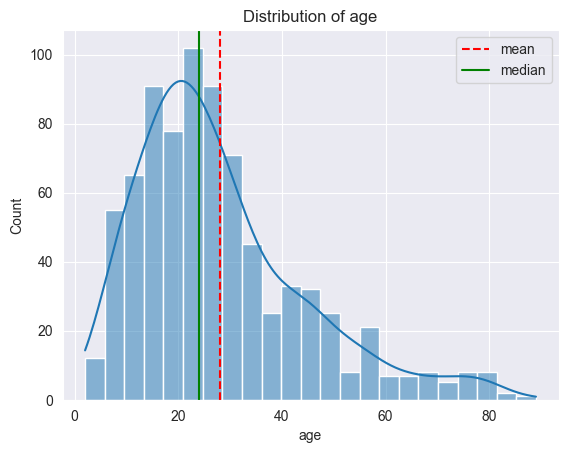

In [84]:
sns.histplot(df["age"], kde=True)
plt.title("Distribution of age")

age_median = df["age"].median()
age_mean = df["age"].mean()

print("mean: ", age_mean)
print("median: ", age_median)

plt.axvline(age_mean, color="red", linestyle="--", label="mean")
plt.axvline(age_median, color="green", linestyle="-", label="median")
plt.legend()

plt.show()

mean:  8.537303106501248
median:  9.605299308


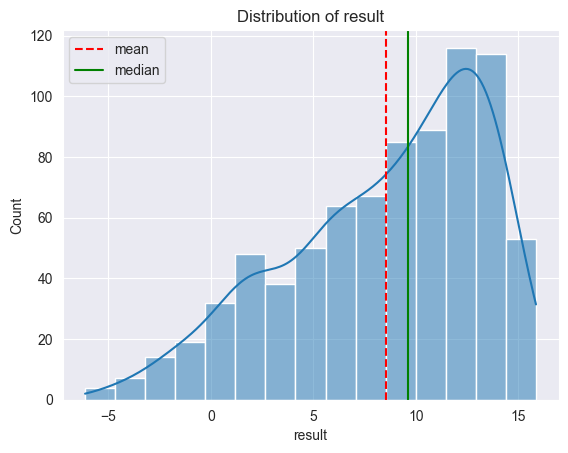

In [85]:
sns.histplot(df["result"], kde=True)
plt.title("Distribution of result")

result_mean = df["result"].mean()
result_median = df["result"].median()

print("mean: ", result_mean)
print("median: ", result_median)

plt.axvline(result_mean, color="red", linestyle="--", label="mean")
plt.axvline(result_median, color="green", linestyle="-", label="median")
plt.legend()

plt.show()

In [86]:
df["ethnicity"] = df["ethnicity"].replace(
    {
    "?": "Others",
    "others": "Others"
    })

In [87]:
df["ethnicity"].unique()

<StringArray>
[         'Others',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',        'Hispanic',           'Asian',         'Turkish',
     'South Asian',          'Latino']
Length: 10, dtype: str

In [88]:
df["relation"] = df["relation"].replace(
    {"?": "Others",
     "Relative": "Others",
     "Parent": "Others",
     "Health care professional": "Others"
    })

In [89]:
df["relation"].unique()


<StringArray>
['Self', 'Others']
Length: 2, dtype: str

In [90]:
# Selecting categorical columns (object and string types) in a future-proof way
object_columns = df.select_dtypes(include=["object", "string"]).columns


In [91]:
print(object_columns)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='str')


In [92]:
encoders = {}

# apply label encoding and store the encoders
for column in object_columns:
  label_encoder = LabelEncoder()
  df[column] = label_encoder.fit_transform(df[column])
  encoders[column] = label_encoder   # saving the encoder for this column


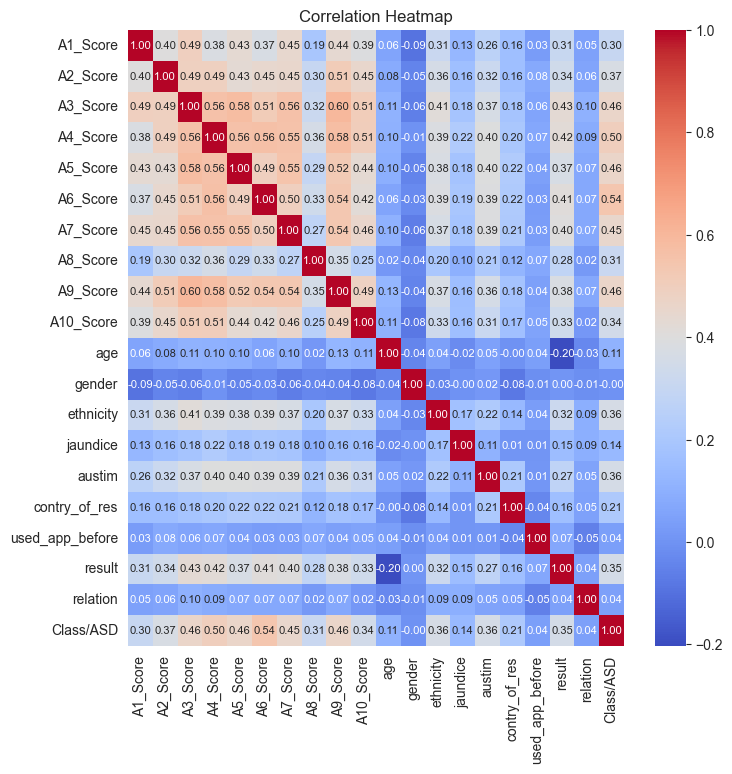

In [93]:
plt.figure(figsize=(8, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    annot_kws={"size": 8}  # Smaller font size for annotations
)
plt.title("Correlation Heatmap", fontsize=12)  # Smaller title font
plt.show()

4. Data preprocessing


In [94]:
def replace_outliers(df, column):
  Q1 = df[column].quantile(0.25)
  Q3 = df[column].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  median = df[column].median()

  # replace outliers with median value
  df[column] = df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

  return df

In [95]:
# replace outliers in the "age" column
df = replace_outliers(df, "age")

# replace outliers in the "result" column
df = replace_outliers(df, "result")

In [96]:
X = df.drop(columns=["Class/ASD"])
y = df["Class/ASD"]

In [97]:
print(X)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0           1         0         1         0         1         0         1   
1           0         0         0         0         0         0         0   
2           1         1         1         1         1         1         1   
3           0         0         0         0         0         0         0   
4           0         0         0         0         0         0         0   
..        ...       ...       ...       ...       ...       ...       ...   
795         0         1         0         0         0         0         0   
796         0         1         1         0         0         1         0   
797         0         0         0         0         0         0         0   
798         0         0         0         0         0         0         0   
799         0         1         0         0         0         0         0   

     A8_Score  A9_Score  A10_Score   age  gender  ethnicity  jaundice  aust

In [98]:
print(y)

0      0
1      0
2      1
3      0
4      0
      ..
795    0
796    0
797    0
798    0
799    0
Name: Class/ASD, Length: 800, dtype: int64


In [99]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [101]:
y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

In [102]:
y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

SMOTE (Synthetic Minority Oversampling technique)

In [103]:
smote = SMOTE(random_state=42)# te balancoj datasetin

In [104]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [105]:
print(y_train_smote.shape)

(1030,)


In [106]:
print(y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


In [107]:

# dictionary of classifiers
models = {
    "decision tree": DecisionTreeClassifier(random_state=42),
    "random forest": RandomForestClassifier(random_state=42),
}

# "decision tree": DecisionTreeClassifier(
#     random_state=42,
#     max_depth=33,
#     min_samples_leaf=41
# ),
#
# "random forest": RandomForestClassifier(
#     random_state=42,
#     n_estimators=21,
#     max_depth=12
# ),


In [108]:
print(models)

{'decision tree': DecisionTreeClassifier(random_state=42), 'random forest': RandomForestClassifier(random_state=42)}


Train each model (Decision Tree & Random Forest)

In [109]:
# dictionary to store results
results = {}

for name, model in models.items():
    print(f"\nTraining model: {name}")

    model.fit(X_train_smote, y_train_smote)

    results[name] = model



Training model: decision tree

Training model: random forest


In [110]:
# store predictions
predictions = {}

for name, model in results.items():
    predictions[name] = model.predict(X_test)


In [111]:
for name, y_pred in predictions.items():
    print("\n" + "=" * 50)
    print(f"Model: {name}")

    print("Accuracy:", accuracy_score(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("Kappa (Decision Tree):",
      cohen_kappa_score(y_test, predictions["decision tree"]))

    print("Kappa (Random Forest):",
      cohen_kappa_score(y_test, predictions["random forest"]))




Model: decision tree
Accuracy: 0.79375

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       124
           1       0.54      0.56      0.55        36

    accuracy                           0.79       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.80      0.79      0.79       160

Confusion Matrix:
[[107  17]
 [ 16  20]]
Kappa (Decision Tree): 0.4143744454303461
Kappa (Random Forest): 0.5808885163453479

Model: random forest
Accuracy: 0.84375

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.90       124
           1       0.63      0.75      0.68        36

    accuracy                           0.84       160
   macro avg       0.78      0.81      0.79       160
weighted avg       0.86      0.84      0.85       160

Confusion Matrix:
[[108  16]
 [  9  27]]
Kappa (Decision Tree): 0.4143744454303461
Kappa (Ran

Decision Tree was used as a baseline classification model.
Random Forest achieved better performance due to ensemble learning, which reduces overfitting and improves generalization.


In [112]:
# Compare model accuracies
comparison = pd.DataFrame({
    "Model": list(predictions.keys()),
    "Accuracy": [
        accuracy_score(y_test, predictions[name])
        for name in predictions
    ]
})

comparison


,Model,Accuracy
0,decision tree,0.79375
1,random forest,0.84375


In [113]:
# Initialize models for hyperparameter tuning
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)


In [114]:
# Hyperparameter grids for tuning

param_grid_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

param_grid_rf = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}


In [115]:
# RandomizedSearchCV setup for hyperparameter tuning

random_search_dt = RandomizedSearchCV(
    estimator=decision_tree,
    param_distributions=param_grid_dt,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)

random_search_rf = RandomizedSearchCV(
    estimator=random_forest,
    param_distributions=param_grid_rf,
    n_iter=20,
    cv=5,
    scoring="accuracy",
    random_state=42
)


In [116]:
# Fit the hyperparameter search models
random_search_dt.fit(X_train_smote, y_train_smote)
random_search_rf.fit(X_train_smote, y_train_smote)


KeyboardInterrupt: 

In [60]:
# Select the best model between Decision Tree and Random Forest

if random_search_dt.best_score_ > random_search_rf.best_score_:
    best_model = random_search_dt.best_estimator_
    best_score = random_search_dt.best_score_
else:
    best_model = random_search_rf.best_estimator_
    best_score = random_search_rf.best_score_

print("Best Model:", best_model)
print("Best Cross-Validation Accuracy:", best_score)


Best Model: RandomForestClassifier(bootstrap=False, max_depth=30, random_state=42)
Best Cross-Validation Accuracy: 0.9291262135922331


In [61]:
# Save the best model
import pickle

with open("best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)


In [62]:
# Evaluate best model on test data

y_test_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))


Accuracy: 0.825
Confusion Matrix:
 [[109  15]
 [ 13  23]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.89       124
           1       0.61      0.64      0.62        36

    accuracy                           0.82       160
   macro avg       0.75      0.76      0.75       160
weighted avg       0.83      0.82      0.83       160



In [63]:
# Load the saved best model
import pickle

with open("best_model.pkl", "rb") as f:
    best_model = pickle.load(f)


In [117]:
def predict_autism(input_data):
    """
    Predicts whether a given input corresponds to an autism case (1) or not (0).
    input_data should be a dictionary with the same features as the training data.
    """

    # Convert input to DataFrame
    input_df = pd.DataFrame([input_data])

    # Encode categorical features using saved encoders   i merr nga test1 test2 i enkodon dhe ben parashikimin
    for column, encoder in encoders.items():
        if column in input_df.columns:
            input_df[column] = encoder.transform(input_df[column])

    # Make prediction
    prediction = best_model.predict(input_df)

    return "Autism (ASD)" if prediction[0] == 1 else "No Autism"


In [118]:
# Test prediction with example inputs

test_case_1 = {
    "A1_Score": 0, "A2_Score": 0, "A3_Score": 0, "A4_Score": 0, "A5_Score": 0,
    "A6_Score": 0, "A7_Score": 0, "A8_Score": 0, "A9_Score": 0, "A10_Score": 0,
    "age": 35,
    "gender": "m",
    "ethnicity": "Others",
    "jaundice": "no",
    "austim": "no",
    "contry_of_res": "India",
    "used_app_before": "no",
    "result": 2.10,
    "relation": "Self"
}

test_case_2 = {
    "A1_Score": 1, "A2_Score": 1, "A3_Score": 1, "A4_Score": 1, "A5_Score": 1,
    "A6_Score": 1, "A7_Score": 1, "A8_Score": 1, "A9_Score": 1, "A10_Score": 1,
    "age": 6,
    "gender": "m",
    "ethnicity": "White-European",
    "jaundice": "yes",
    "austim": "yes",
    "contry_of_res": "United States",
    "used_app_before": "no",
    "result": 15.5,
    "relation": "Self"
}

print("Prediction for Case 1:", predict_autism(test_case_1))
print("Prediction for Case 2:", predict_autism(test_case_2))


Prediction for Case 1: No Autism
Prediction for Case 2: Autism (ASD)


In [78]:
# scaling the features
scaler = StandardScaler()

X_train_nn = scaler.fit_transform(X_train_smote)
X_test_nn = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_smote.to_numpy(), dtype=torch.float32).unsqueeze(1)

X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype=torch.float32).unsqueeze(1)

print(X_train_tensor.shape, y_train_tensor.shape)


torch.Size([1030, 19]) torch.Size([1030, 1])


In [80]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x



In [81]:
# Reproducibility
torch.manual_seed(42)

input_dim = X_train_tensor.shape[1]

model_nn = NeuralNetwork(input_dim)

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.001)

model_nn


NeuralNetwork(
  (fc1): Linear(in_features=19, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
)

In [82]:
epochs = 300 # number of training epochs

for epoch in range(epochs):
    model_nn.train()

    optimizer.zero_grad()

    logits = model_nn(X_train_tensor)
    loss = criterion(logits, y_train_tensor)

    loss.backward()
    optimizer.step()

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")


Epoch 000 | Loss: 0.6844
Epoch 005 | Loss: 0.6488
Epoch 010 | Loss: 0.6214
Epoch 015 | Loss: 0.5835
Epoch 020 | Loss: 0.5463
Epoch 025 | Loss: 0.5092
Epoch 030 | Loss: 0.4639
Epoch 035 | Loss: 0.4293
Epoch 040 | Loss: 0.4022
Epoch 045 | Loss: 0.3902
Epoch 050 | Loss: 0.3720
Epoch 055 | Loss: 0.3678
Epoch 060 | Loss: 0.3589
Epoch 065 | Loss: 0.3441
Epoch 070 | Loss: 0.3504
Epoch 075 | Loss: 0.3428
Epoch 080 | Loss: 0.3304
Epoch 085 | Loss: 0.3238
Epoch 090 | Loss: 0.3291
Epoch 095 | Loss: 0.3167
Epoch 100 | Loss: 0.3165
Epoch 105 | Loss: 0.3112
Epoch 110 | Loss: 0.3128
Epoch 115 | Loss: 0.3055
Epoch 120 | Loss: 0.2940
Epoch 125 | Loss: 0.3021
Epoch 130 | Loss: 0.2927
Epoch 135 | Loss: 0.3075
Epoch 140 | Loss: 0.2958
Epoch 145 | Loss: 0.2887
Epoch 150 | Loss: 0.2978
Epoch 155 | Loss: 0.2824
Epoch 160 | Loss: 0.2786
Epoch 165 | Loss: 0.2839
Epoch 170 | Loss: 0.2726
Epoch 175 | Loss: 0.2740
Epoch 180 | Loss: 0.2700
Epoch 185 | Loss: 0.2611
Epoch 190 | Loss: 0.2531
Epoch 195 | Loss: 0.2478


In [83]:
model_nn.eval()

with torch.no_grad():
    logits = model_nn(X_test_tensor)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).float()

accuracy_nn = (preds == y_test_tensor).float().mean()

print(f"Neural Network Accuracy: {accuracy_nn.item() * 100:.2f}%")


Neural Network Accuracy: 83.75%


In [84]:
from sklearn.metrics import confusion_matrix, classification_report

# Convert tensors to numpy
y_true = y_test_tensor.numpy()
y_pred = preds.numpy()

print("Confusion Matrix (Neural Network):")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report (Neural Network):")
print(classification_report(y_true, y_pred))



Confusion Matrix (Neural Network):
[[105  19]
 [  7  29]]

Classification Report (Neural Network):
              precision    recall  f1-score   support

         0.0       0.94      0.85      0.89       124
         1.0       0.60      0.81      0.69        36

    accuracy                           0.84       160
   macro avg       0.77      0.83      0.79       160
weighted avg       0.86      0.84      0.84       160



In [85]:
final_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Neural Network"],
    "Accuracy": [
        comparison.loc[comparison["Model"] == "decision tree", "Accuracy"].values[0],
        comparison.loc[comparison["Model"] == "random forest", "Accuracy"].values[0],
        accuracy_nn.item()
    ]
})

final_comparison


,Model,Accuracy
0,Decision Tree,0.79375
1,Random Forest,0.84375
2,Neural Network,0.83750
